# NLP Analysis of Political Manifestos

This notebook analyses political manifestos from the Archelec corpus using NLP techniques.

We study:
- semantic density (linguistic richness)
- semantic similarity (TF-IDF vs embeddings)
- ranking of similar documents

In [90]:
!pip install pandas numpy matplotlib scikit-learn spacy sentence-transformers tqdm
!python -m spacy download fr_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 29.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [91]:
import os
import re
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import spacy
from sentence_transformers import SentenceTransformer

## Data Loading

We extract the dataset from the uploaded zip file.

In [92]:
# NOTE: dataset not included in the repository.
# Place the dataset inside the "data/" folder before running.

import zipfile

zip_path = "/content/legislatives (1).zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Extraction completed")


Extraction completed


In [93]:
folder = "/content/data/text_files/1988/legislatives"

data = []

for filename in os.listdir(folder):
    if filename.endswith(".txt"):
        with open(os.path.join(folder, filename), "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
        data.append({"id": filename, "text": text})

df = pd.DataFrame(data)

print("Number of documents:", len(df))
df.head()

Number of documents: 3628


,id,text
0,EL176_L_1988_06_073_03_2_PF_02.txt,Sciences Po / fonds CEVIPOF\nUN APPEL DE MICHE...
1,EL174_L_1988_06_028_02_1_PF_01.txt,Sciences Po / fonds CEVIPOF\nÉLECTIONS LÉGISLA...
2,EL174_L_1988_06_014_03_2_PF_01.txt,Elections Législatives de juin 1988\n3e CIRCON...
3,EL176_L_1988_06_069_05_1_PF_01.txt,Sciences Po / fonds CEVIPOF\nELECTION LEGISLAT...
4,EL174_L_1988_06_014_06_1_PF_01.txt,Sciences Po / fonds CEVIPOF\nRaymond PROSPER-P...


## Text Preprocessing

We clean the text by removing noise and normalizing it.

In [94]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'[^a-zàâçéèêëîïôûùüÿñæœ\s]', ' ', text)
    return text

df["clean_text"] = df["text"].apply(clean_text)

## Exploratory Data Analysis

We analyse document lengths.

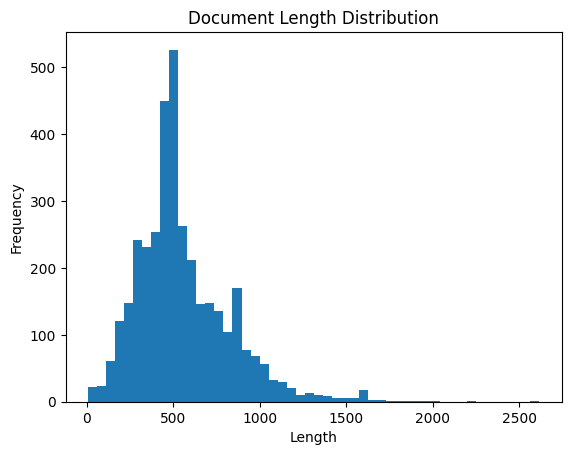

<Figure size 640x480 with 0 Axes>

In [95]:
df["length"] = df["clean_text"].apply(lambda x: len(x.split()))

plt.hist(df["length"], bins=50)
plt.title("Document Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

plt.savefig("length_plot.png")

## Semantic Density

We define semantic density as the ratio of content words to total words.

In [96]:
nlp = spacy.load("fr_core_news_sm")

def semantic_density(text):
    doc = nlp(text[:1000])
    content = [t for t in doc if t.pos_ in ["NOUN","VERB","ADJ"]]
    return len(content) / len(doc) if len(doc) > 0 else 0

df["density"] = df["clean_text"].apply(semantic_density)

## Density Distribution

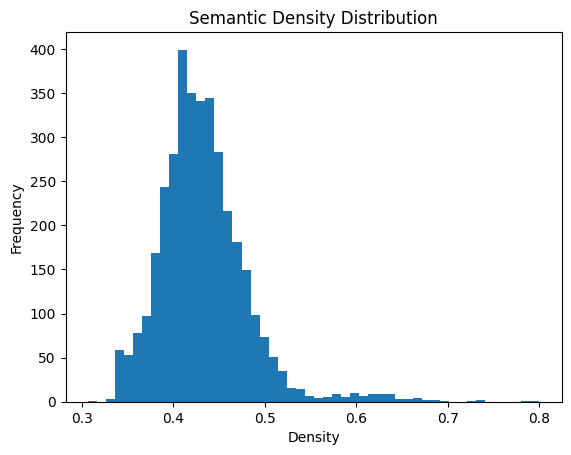

<Figure size 640x480 with 0 Axes>

In [97]:
plt.hist(df["density"], bins=50)
plt.title("Semantic Density Distribution")
plt.xlabel("Density")
plt.ylabel("Frequency")
plt.show()

plt.savefig("density_plot.png")

In [98]:
print("LOW DENSITY EXAMPLE:\n")
print(df.sort_values("density").iloc[0]["text"][:500])

print("\nHIGH DENSITY EXAMPLE:\n")
print(df.sort_values("density", ascending=False).iloc[0]["text"][:500])

LOW DENSITY EXAMPLE:

Madame, Mademoiselle, Monsieur,
Dimanche vous avez mis le Parti Socialiste en ballotage dans notre circonscription. Pourquoi ?
Parce que, comme les autres Français, vous ne voulez pas de la toute puissance d'un seul parti en France.
Parce que les Socialistes ne représentent qu'un Français sur trois. Alors que la Présidence de la République est entre leurs mains, il serait malsain que l'Assemblée Nationale leur donne 100% des pouvoirs.
Parce que les Socialistes, bien qu'ils ne représentent qu'un 

HIGH DENSITY EXAMPLE:

Département : PARIS 18ème Circonscription
Sylvie EDMONDSON suppléante Marie-José SERIZIER
PARTI OUVRIER EUROPÉEN
Sciences Po / fonds CEVIPOV


## TF-IDF Representation

We compute a lexical baseline using TF-IDF.

In [99]:
vectorizer = TfidfVectorizer(max_features=10000)
tfidf_matrix = vectorizer.fit_transform(df["clean_text"])

tfidf_sim = cosine_similarity(tfidf_matrix)

## Embedding-based Representation

We use sentence embeddings to capture semantic relationships.

In [100]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df["clean_text"].tolist(), show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/114 [00:00<?, ?it/s]

## Similarity Computation

emb_sim = cosine_similarity(embeddings)

## Ranking Task

We retrieve the most similar documents given a query.

In [101]:
def get_top_k(sim_matrix, idx, k=5):
    scores = sim_matrix[idx]
    return scores.argsort()[::-1][1:k+1]

In [102]:
query_idx = 0

print("QUERY:\n")
print(df.iloc[query_idx]["text"][:500])

print("\nTOP 5 SIMILI:\n")

top_docs = get_top_k(emb_sim, query_idx)

for i in top_docs:
    print(f"\n--- Documento {i} ---\n")
    print(df.iloc[i]["text"][:300])

QUERY:

Sciences Po / fonds CEVIPOF
UN APPEL DE MICHEL BARNIER ET JEAN BLANC
Chère Madame, Chère Mademoiselle, Cher Monsieur,
Depuis de nombreuses années, nous travaillons ensemble au sein de l'Union pour la Savoie pour faire de notre département une région forte et solidaire.
Ce travail tenace a toujours été compris et approuvé par les Savoyards comme en témoigne le scrutin du premier tour de cette élection législative.
Michel BOUVARD et Suzanne JACON appartiennent à cette « équipe de Savoie ». Ils peu

TOP 5 SIMILI:


--- Documento 257 ---

Sciences Po / fonds CEVIPOF
RÉPUBLIQUE FRANÇAISE 3e CIRCONSCRIPTION DE LA SAVOIE ÉLECTIONS LÉGISLATIVES DES 5 ET 12 JUIN 1988
Chère Madame, Chère Mademoiselle, Cher Monsieur,
La subite et brutale dissolution de l'Assemblée Nationale a entraîné des élections législatives qui auront lieu les 5 et 12 j

--- Documento 2242 ---

Gratien FERRARI Jean Bollon
Sciences Po / fonds CEVIPOF
le Coeur et l'Energie!
UNION POUR LA SAVOIE
ELECTIONS LEGISLATIVES-1 

## Model Comparison

In [103]:
print("TF-IDF:", get_top_k(tfidf_sim, query_idx))
print("EMBEDDINGS:", get_top_k(emb_sim, query_idx))

TF-IDF: [ 257 2242  192 3108   18]
EMBEDDINGS: [ 257 2242  439  514 2773]


## Discussion

Semantic density highlights differences in informational content.  
Embedding-based similarity captures deeper relationships than TF-IDF.  

Limitations include OCR noise and simplified linguistic assumptions.

## Conclusion

NLP techniques allow meaningful analysis of political texts, both linguistically and semantically.